# CG Map-Making Demo

Wiener filter sky reconstruction at 25 MHz using `lusee.mapmaker`.  
Reproduces the approach of [Camacho et al. 2026](https://arxiv.org/abs/2508.16773).

Requires `LUSEE_DRIVE_DIR` pointing to the LuSEE-Night data (beam + sky FITS files).

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import time
import jax
import jax.numpy as jnp
import numpy as np
import lusee
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline

The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
DRIVE = os.environ.get("LUSEE_DRIVE_DIR", "/fs/zack/LuSEE-Night/")
BEAM_FILE = DRIVE + "Simulations/BeamModels/LanderRegolithComparison/eight_layer_regolith/hfss_lbl_3m_75deg.fits"
SKY_FILE = DRIVE + "Simulations/SkyModels/ULSA_32_ddi_smooth.fits"

LMAX = 32
FREQ = np.array([25.0])  # single frequency
OBS_RANGE = "2025-02-01 13:00:00 to 2025-02-28 13:00:00"  # full sidereal rotation

## Build instrument and simulate data

In [3]:
sim, beams, obs = lusee.mapmaker.build_instrument(
    beam_file=BEAM_FILE, obs_range=OBS_RANGE, freq=FREQ, lmax=LMAX,
    dt_sec=7200.0,  # paper: Δt = 7200 s (2-hour integration)
)

# Load ULSA sky at 25 MHz
sky_full = lusee.sky.FitsSky(SKY_FILE, lmax=LMAX)
fi = int(np.argmin(np.abs(np.asarray(sky_full.freq) - 25.0)))
sky = lusee.sky.HealpixSky(
    sky_full.Nside, LMAX,
    maps=[hp.alm2map(np.asarray(sky_full.mapalm[fi]), sky_full.Nside, verbose=False)],
    freq=FREQ, frame="galactic",
)

# Simulate noiseless data + add radiometric noise (Camacho+ Eq. 9)
data_clean = sim.simulate(sky=sky)
sigma = lusee.mapmaker.compute_radiometric_noise(
    data_clean, delta_f_hz=1e6, delta_t_sec=7200.0,
)
data = data_clean + sigma * jax.random.normal(jax.random.PRNGKey(42), data_clean.shape)

sigma_med = float(jnp.median(sigma))
print(f"{len(obs.times)} timesteps, {data.shape[1]} channels, "
      f"median σ = {sigma_med:.3f} K, SNR ~ {float(jnp.std(data_clean))/sigma_med:.0f}")

  intializing beam combination N x N ...
  intializing beam combination E x E ...
  intializing beam combination S x S ...
  intializing beam combination W x W ...
  intializing beam combination N x S ...
    cross power is 0.0 ... 0.0 
  intializing beam combination E x W ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x E ...
    cross power is 0.0 ... 0.0 
  intializing beam combination E x S ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x W ...
    cross power is 0.0 ... 0.0 
  intializing beam combination S x W ...
    cross power is 0.0 ... 0.0 
325 timesteps, 16 channels, median σ = 0.128 K, SNR ~ 72792


## Wiener filter solve via CG

The sky is real but the beams are complex (complex E-field patterns, complex cross-correlations). `lusee.mapmaker.solve` uses a real parameterization $\theta = [\mathrm{Re}(a_{\ell m});\, \mathrm{Im}(a_{\ell, m>0})]$ so that CG operates on a real symmetric system. JAX traces through all the complex beam math internally and returns real gradients — no Wirtinger conjugation needed. See `docs/wirtinger_cg.md`.

A diagonal preconditioner $M = \mathrm{diag}(C_\ell)$ is applied by default to equalize the ~5 orders of magnitude in $S^{-1}$, which dramatically improves CG convergence.

In [4]:
S_inv = lusee.mapmaker.compute_cl_prior(sky, LMAX)

t0 = time.time()
sky_hat = lusee.mapmaker.solve(sim, data, sky, sigma, signal_prior=S_inv, maxiter=500)
print(f"Solved in {time.time() - t0:.0f}s")

Solved in 399s


## Sky maps: input vs recovered

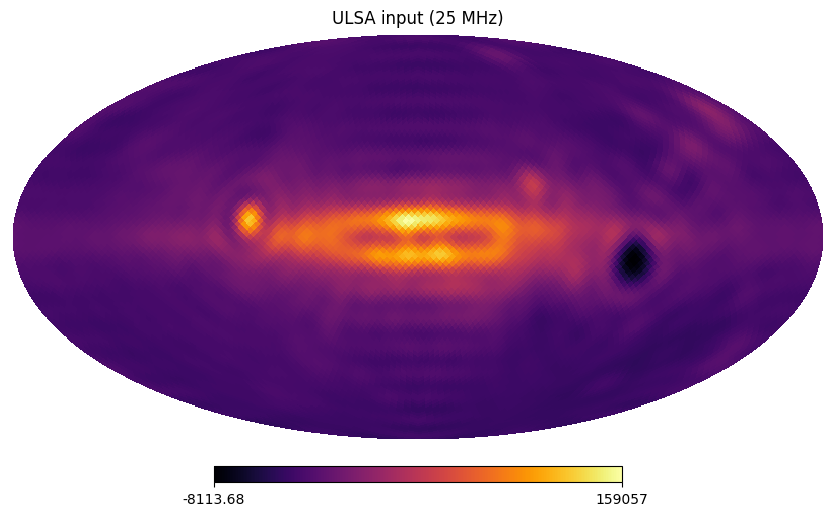

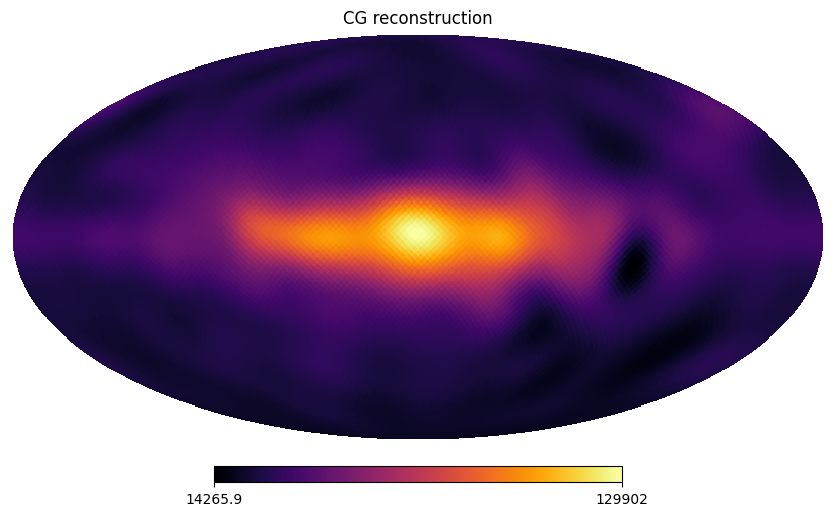

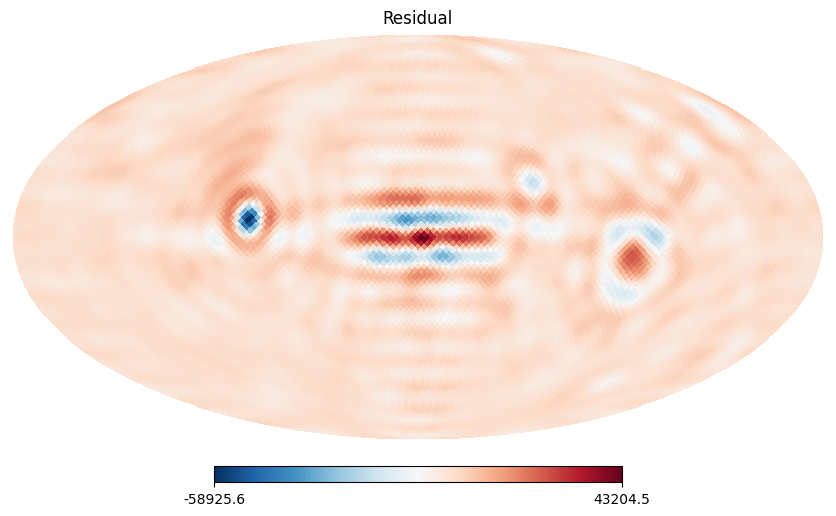

In [5]:
true_alm = np.asarray(sky.mapalm[0])
rec_alm = np.asarray(sky_hat[0])
true_map = hp.alm2map(true_alm, sky.Nside, verbose=False)
rec_map = hp.alm2map(rec_alm, sky.Nside, verbose=False)
resid = rec_map - true_map

hp.mollview(true_map, title="ULSA input (25 MHz)", cmap="inferno")
hp.mollview(rec_map, title="CG reconstruction", cmap="inferno")
hp.mollview(resid, title="Residual", cmap="RdBu_r")

In [6]:
# Check convergence and reconstruction quality
print(f"rec_map range: [{rec_map.min():.0f}, {rec_map.max():.0f}] K")
print(f"true_map range: [{true_map.min():.0f}, {true_map.max():.0f}] K")
print(f"resid range: [{resid.min():.0f}, {resid.max():.0f}] K")
print(f"a00: true={true_alm[0].real:.0f}, rec={rec_alm[0].real:.0f}, err={abs(rec_alm[0]-true_alm[0]):.0f}")

rho_l = hp.alm2cl(true_alm, rec_alm) / np.sqrt(
    hp.alm2cl(true_alm) * hp.alm2cl(rec_alm) + 1e-30)
print(f"mean rho(1..10) = {np.nanmean(rho_l[1:11]):.4f}")
for l in range(min(6, LMAX+1)):
    print(f"  l={l}: rho={rho_l[l]:.4f}")

rec_map range: [14266, 129902] K
true_map range: [-8114, 159057] K
resid range: [-58926, 43204] K
a00: true=134714, rec=135195, err=481
mean rho(1..10) = 0.9906
  l=0: rho=1.0000
  l=1: rho=0.9997
  l=2: rho=0.9997
  l=3: rho=0.9991
  l=4: rho=0.9988
  l=5: rho=0.9973


## Reconstruction fidelity: $\rho_\ell$ vs $\ell$

Cross-correlation coefficient between true and recovered sky per multipole (cf. Camacho+ 2026 Fig 5).

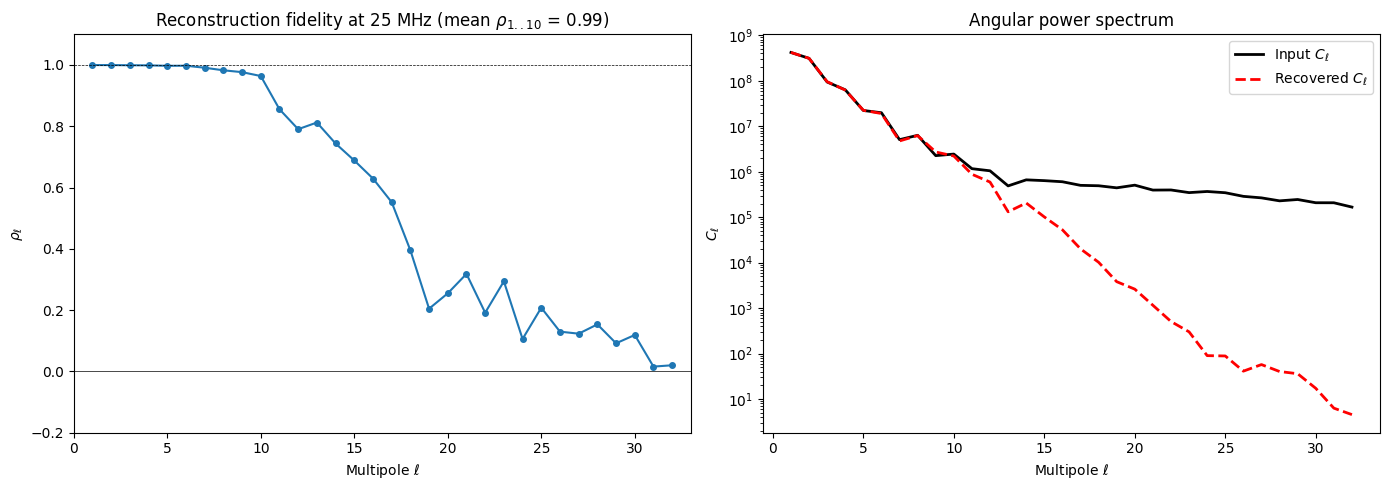

In [7]:
cl_true = hp.alm2cl(true_alm)
cl_rec = hp.alm2cl(rec_alm)
cl_cross = hp.alm2cl(true_alm, rec_alm)
rho = cl_cross / np.sqrt(cl_true * cl_rec + 1e-30)
ell = np.arange(len(rho))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# rho vs ell
ax1.plot(ell[1:LMAX+1], rho[1:LMAX+1], 'o-', ms=4)
ax1.axhline(0, color='k', lw=0.5)
ax1.axhline(1, color='k', lw=0.5, ls='--')
ax1.set_xlabel(r"Multipole $\ell$")
ax1.set_ylabel(r"$\rho_\ell$")
ax1.set_title(f"Reconstruction fidelity at 25 MHz (mean $\\rho_{{1..10}}$ = {np.nanmean(rho[1:11]):.2f})")
ax1.set_ylim(-0.2, 1.1)
ax1.set_xlim(0, LMAX + 1)

# Power spectra
ax2.semilogy(ell[1:LMAX+1], cl_true[1:LMAX+1], 'k-', label="Input $C_\\ell$", lw=2)
ax2.semilogy(ell[1:LMAX+1], cl_rec[1:LMAX+1], 'r--', label="Recovered $C_\\ell$", lw=2)
ax2.set_xlabel(r"Multipole $\ell$")
ax2.set_ylabel(r"$C_\ell$")
ax2.set_title("Angular power spectrum")
ax2.legend()

plt.tight_layout()